## HW #2 - Data Acquisition, Processing, and Communication

For this assignment, reservoir management requests recommendations to balance water storage and mitigate flooding potential for the previous water year on April 1st, 2025, for a reservoir of your choice in the Upper Colorado River Basin, or approved by the instructor. Your sub-basin/reservoir of choice should have at least 1 SNOTEL station, a USGS streamflow gauge near the inlet of the reservoir that is hydrologically relevant to the upstream SNOTEL site(s), and no significant reservoir upstream.

USGS gauge at a reservoir inlet = [10133980](https://waterdata.usgs.gov/monitoring-location/USGS-10133980/#dataTypeId=continuous-00065-0&period=P7D&showFieldMeasurements=true) East Canyon Creek above East Canyon Res near Morgan, UT

### 1. Area of interest

This section includes a map of the USGS gauge and SNOTEL station(s)

In [ ]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import warnings
warnings.filterwarnings("ignore")

#### USGS and basin map

In [2]:
nldi = NLDI()
usgs_gage_id = "10133980" 

In [3]:
basinname = 'EastCanyonBasin'

#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file(f"files/{basinname}.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

In [ ]:
# if needed to trust map below
#!jupyter trust *.ipynb

Signing notebook: res_mgmt.ipynb


In [12]:
# create map of USGS gauge and basin
m = mapping.basin_mapping(basin, site_feature)
m

In [17]:
# save png of basin map with topo basemap
os.makedirs("images", exist_ok=True)
basin_web = basin.to_crs(epsg=3857)
site_web = site_feature.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))
basin_web.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1, alpha=0.55)
site_web.plot(ax=ax, color="blue", markersize=45)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)
ax.set_axis_off()
fig.savefig("./images/east_canyon_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)

#### SNOTEL sites within basin

In [4]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,684_UT_SNTL,Parleys Summit,SNOTEL,2311.907959,40.761841,-111.629173,Utah,160201020103,12TVL,Western Rocky Mountains,1978-10-01,2026-03-26,True,POINT (-111.62917 40.76184)
1,814_UT_SNTL,Thaynes Canyon,SNOTEL,2813.303955,40.623501,-111.533218,Utah,160201020101,12TVK,Western Rocky Mountains,1988-06-20,2026-03-26,True,POINT (-111.53322 40.6235)


In [6]:
# add snotel sites to map
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

In [5]:
# save png of basin map with topo basemap and labeled SNOTEL sites
os.makedirs("images", exist_ok=True)
basin_web = basin.to_crs(epsg=3857)
site_web = site_feature.to_crs(epsg=3857)
snotel_web = gdf_in_bbox.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))
basin_web.plot(ax=ax, color="lightblue", edgecolor="darkblue", linewidth=1, alpha=0.55)
snotel_web.plot(ax=ax, color="purple", markersize=45, marker="^", edgecolor="black", linewidth=0.4)
site_web.plot(ax=ax, color="blue", markersize=45)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

for _, row in snotel_web.iterrows():
    label = str(row.get("name", row.get("code", "SNOTEL")))
    ax.annotate(
        label,
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        color="black",
        bbox={"facecolor": "white", "alpha": 0.7, "pad": 1, "edgecolor": "none"},
    )

gage_x = site_web.geometry.iloc[0].x
gage_y = site_web.geometry.iloc[0].y
ax.annotate(
    f"USGS {usgs_gage_id}",
    (gage_x, gage_y),
    xytext=(6, -10),
    textcoords="offset points",
    fontsize=7,
    color="navy",
    bbox={"facecolor": "white", "alpha": 0.8, "pad": 1, "edgecolor": "none"},
 )

ax.set_axis_off()
fig.savefig("./images/east_canyon_map_snotel.png", dpi=300, bbox_inches="tight")
plt.close(fig)

### 2. SWE analysis for SNOTEL sites

Create figures or tables that communicate the historical range of SWE, similar to a SNOTEL site figure

In [5]:
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,684_UT_SNTL,Parleys Summit,SNOTEL,2311.907959,40.761841,-111.629173,Utah,160201020103,12TVL,Western Rocky Mountains,1978-10-01,2026-03-26,True,POINT (-111.62917 40.76184)
1,814_UT_SNTL,Thaynes Canyon,SNOTEL,2813.303955,40.623501,-111.533218,Utah,160201020101,12TVK,Western Rocky Mountains,1988-06-20,2026-03-26,True,POINT (-111.53322 40.6235)


In [8]:
# retrieve snotel data
# Use the getData module to retrieve data 
OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

for i in gdf_in_bbox.index:
    getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.state[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)


Start retrieving data for Parleys Summit, 684_UT_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/684:Ut:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-25/WTEQ::value?fitToScreen=false


MaxRetryError: HTTPSConnectionPool(host='wcc.sc.egov.usda.gov', port=443): Max retries exceeded with url: /reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/684:Ut:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-25/WTEQ::value?fitToScreen=false (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1017)')))

In [ ]:
# Create dict for sites
sites = list(gdf_in_bbox.code)
stateab = 'Utah'
sitedict = dict()
WY = 2025

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

#rename dict keys to be more useful
sitedict['PARLEYS'] = sitedict.pop('684_UT_SNTL')
sitedict['THAYNES'] = sitedict.pop('814_UT_SNTL')

684_UT_SNTL
Skipping 2026 - partial water year (175 days)
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
814_UT_SNTL
Skipping 1988 - partial water year (103 days)
Skipping 2026 - partial water year (175 days)
Dropping 2025 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


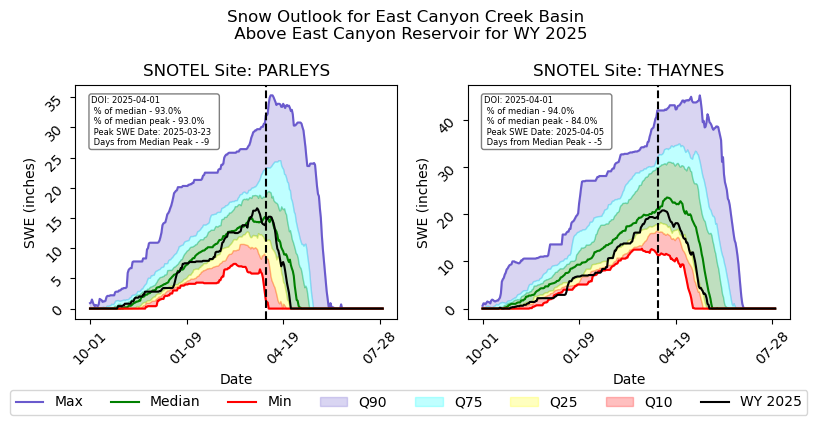

In [11]:
watershed = "East Canyon Creek"
AOI = 'Above East Canyon Reservoir'
DOI = '04-01' #must be in MM-DD form
WY = 2025

SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)

### 3. USGS streamflow analysis

Create one figure and or Table illustrating the historical range of streamflow volume for April, May, June, July, August, and September (hint: this figure should have subplots in a 2x3 or 3x2 format).

In [ ]:
#get streamflow information using the NWIS id for the gage and ghte get_usgs_streamflow function in getData.py 
streamflow = getData.get_usgs_streamflow(usgs_gage_id)

streamflow.head()


#PUT MOST OF THIS SECTION IN A FUNCTION



Retrieving data for Site: 10133980 from 1980-01-01 to 2026-03-26...


,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2007-07-06 00:00:00+00:00,10133980,8.30,"A, e"
2007-07-07 00:00:00+00:00,10133980,8.34,A
2007-07-08 00:00:00+00:00,10133980,8.52,A
2007-07-09 00:00:00+00:00,10133980,7.69,A
2007-07-10 00:00:00+00:00,10133980,9.55,A


In [20]:
#clean the data 
cleaned = dataprocessing.clean_nwis_dataframe(streamflow)
#set the index name to Date
cleaned.index.name = "Date"
cleaned.head()

,site_no,flow_cfs
Date,,
2007-07-06,10133980,8.30
2007-07-07,10133980,8.34
2007-07-08,10133980,8.52
2007-07-09,10133980,7.69
2007-07-10,10133980,9.55


In [21]:
#convert to SI units
cleaned['flow_cfs'] = cleaned['flow_cfs'] * 0.0283168
cleaned.rename(columns={'flow_cfs': 'flow_cms'}, inplace=True)

In [50]:
#get summary stats for streamflow by month for April through September
cleaned['month'] = cleaned.index.month
cleaned.groupby('month')['flow_cms'].describe().loc[4:9]

#save cleaned data to csv
#cleaned.to_csv('files/cleaned_streamflow.csv')

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
4,540.0,3.398310,2.816571,0.696593,1.611226,2.111017,4.615638,19.397008
5,558.0,4.041218,3.554963,0.874989,1.728033,2.609393,4.785539,20.727898
6,540.0,2.247997,2.308144,0.317148,0.685974,1.312484,2.980343,11.326720
7,584.0,0.729354,0.790027,0.145548,0.328475,0.523861,0.784375,6.541181
8,589.0,0.459580,0.267052,0.102790,0.272691,0.410594,0.549346,1.888731
9,570.0,0.472428,0.201508,0.178396,0.342633,0.427584,0.560673,2.157740


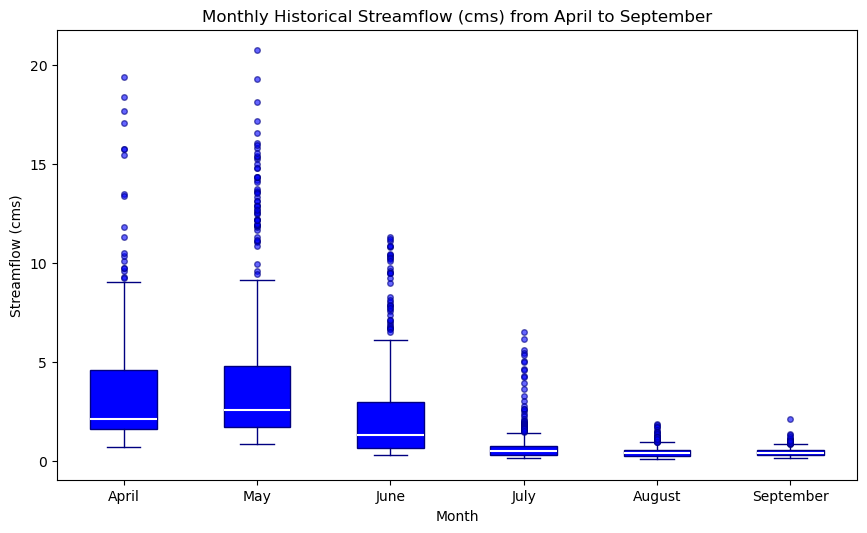

In [ ]:
#create box plots of flow_cms for each month, April through September

fig, ax = plt.subplots(figsize=(10, 6))
cleaned_months = cleaned[cleaned['month'].between(4, 9)]
cleaned_months.boxplot(
    column='flow_cms',
    by='month',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='blue', color='navy', alpha=1.0),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    medianprops=dict(color='white', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='blue', markeredgecolor='navy', markersize=4, alpha=0.6),
)
ax.set_title('Monthly Historical Streamflow (cms) from April to September')
ax.set_xlabel('Month')
ax.set_ylabel('Streamflow (cms)')
plt.suptitle('')
ax.set_xticklabels(['April', 'May', 'June', 'July', 'August', 'September'])
plt.grid(False)

# plt.savefig('./images/streamflow_boxplot.png', dpi=300, bbox_inches='tight')
# plt.close(fig)

### 4. Compare and contrast Peak SWE with streamflow

Create one figure with six parity plots relating historical Peak SWE with April, May, June, July, August, and September streamflow

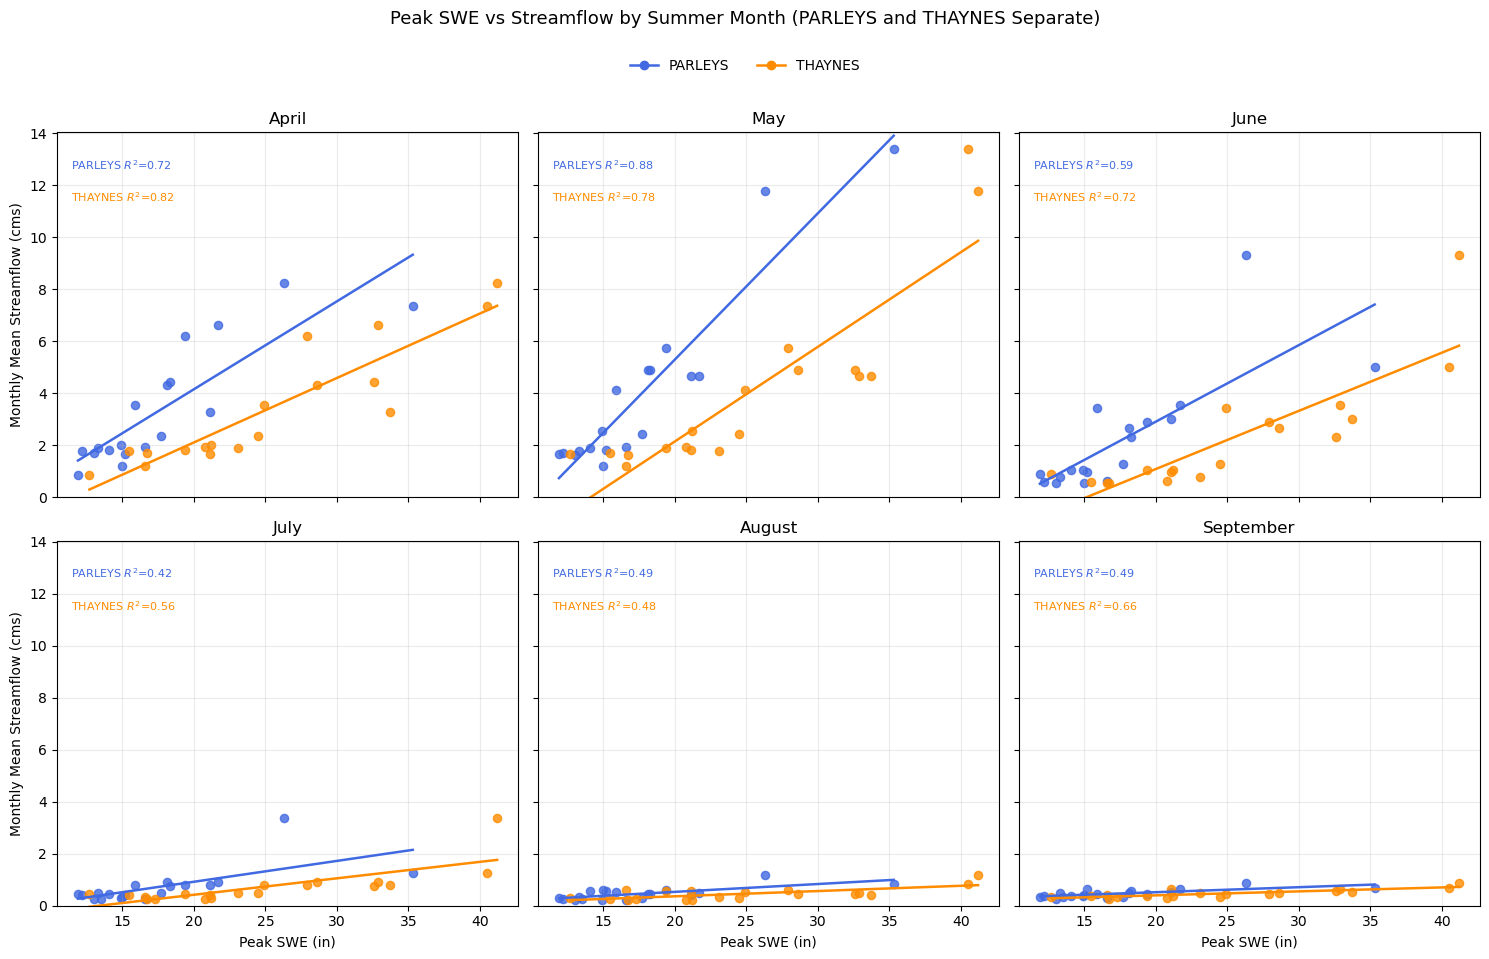

,WY,peak_swe_in_PARLEYS,peak_swe_in_THAYNES
0,1988,14.300008,0.000000
1,1989,20.600011,25.500014
2,1990,15.300008,21.000011
3,1991,17.100009,21.000011
4,1992,7.500004,16.000009


In [62]:
# Compare peak SWE (PARLEYS vs THAYNES separately) vs monthly streamflow (Apr-Sep)
site_code_map = {'PARLEYS': '684_UT_SNTL', 'THAYNES': '814_UT_SNTL'}
peak_frames = []

for site_name, site_code in site_code_map.items():
    sfile = f"files/SNOTEL/df_{site_code}_Utah_SNTL.csv"
    sraw = pd.read_csv(sfile)
    sraw['Date'] = pd.to_datetime(sraw['Date'])
    sraw['swe_in'] = sraw['Snow Water Equivalent (m) Start of Day Values'].fillna(0) * 39.3701
    sraw['WY'] = sraw['Date'].dt.year + (sraw['Date'].dt.month >= 10).astype(int)

    site_peak = sraw.groupby('WY', as_index=False)['swe_in'].max()
    site_peak.rename(columns={'swe_in': f'peak_swe_in_{site_name}'}, inplace=True)
    peak_frames.append(site_peak)

# Merge both-site peak SWE tables on WY
peak_both = peak_frames[0].merge(peak_frames[1], on='WY', how='inner')

# Build WY and monthly mean streamflow
flow = cleaned.copy()
flow.index = pd.to_datetime(flow.index)
flow['WY'] = flow.index.year + (flow.index.month >= 10).astype(int)
flow['month'] = flow.index.month

monthly_flow = (
    flow[flow['month'].between(4, 9)]
    .groupby(['WY', 'month'], as_index=False)['flow_cms']
    .mean()
    .rename(columns={'flow_cms': 'monthly_mean_flow_cms'})
)

# Join SWE and streamflow for plotting
plot_df = monthly_flow.merge(
    peak_both[['WY', 'peak_swe_in_PARLEYS', 'peak_swe_in_THAYNES']],
    on='WY',
    how='inner',
)

# Global axis limits for consistent comparison across panels
x_all = pd.concat([plot_df['peak_swe_in_PARLEYS'], plot_df['peak_swe_in_THAYNES']], axis=0)
y_all = plot_df['monthly_mean_flow_cms']
x_pad = 0.05 * (x_all.max() - x_all.min()) if x_all.max() > x_all.min() else 1.0
y_pad = 0.05 * (y_all.max() - y_all.min()) if y_all.max() > y_all.min() else 0.2
xlim = (x_all.min() - x_pad, x_all.max() + x_pad)
ylim = (max(0, y_all.min() - y_pad), y_all.max() + y_pad)

# Create six parity plots (Apr-Sep)
month_names = {4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August', 9: 'September'}
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, m in enumerate(range(4, 10)):
    ax = axes[i]
    md = plot_df[plot_df['month'] == m].dropna()

    y = md['monthly_mean_flow_cms'].values
    x_parleys = md['peak_swe_in_PARLEYS'].values
    x_thaynes = md['peak_swe_in_THAYNES'].values

    # Scatter points by site
    ax.scatter(x_parleys, y, color='royalblue', alpha=0.8, s=35)
    ax.scatter(x_thaynes, y, color='darkorange', alpha=0.8, s=35)

    # PARLEYS regression + R2
    if len(md) >= 2 and np.std(x_parleys) > 0:
        slope_p, intercept_p = np.polyfit(x_parleys, y, 1)
        xline_p = np.linspace(x_parleys.min(), x_parleys.max(), 100)
        yline_p = slope_p * xline_p + intercept_p
        ax.plot(xline_p, yline_p, color='royalblue', linewidth=1.8)

        yhat_p = slope_p * x_parleys + intercept_p
        ss_res_p = np.sum((y - yhat_p) ** 2)
        ss_tot_p = np.sum((y - y.mean()) ** 2)
        r2_p = 1 - (ss_res_p / ss_tot_p) if ss_tot_p != 0 else np.nan
        ax.text(0.03, 0.93, f"PARLEYS $R^2$={r2_p:.2f}", transform=ax.transAxes, va='top', fontsize=8, color='royalblue')

    # THAYNES regression + R2
    if len(md) >= 2 and np.std(x_thaynes) > 0:
        slope_t, intercept_t = np.polyfit(x_thaynes, y, 1)
        xline_t = np.linspace(x_thaynes.min(), x_thaynes.max(), 100)
        yline_t = slope_t * xline_t + intercept_t
        ax.plot(xline_t, yline_t, color='darkorange', linewidth=1.8)

        yhat_t = slope_t * x_thaynes + intercept_t
        ss_res_t = np.sum((y - yhat_t) ** 2)
        ss_tot_t = np.sum((y - y.mean()) ** 2)
        r2_t = 1 - (ss_res_t / ss_tot_t) if ss_tot_t != 0 else np.nan
        ax.text(0.03, 0.84, f"THAYNES $R^2$={r2_t:.2f}", transform=ax.transAxes, va='top', fontsize=8, color='darkorange')

    ax.set_title(month_names[m])
    ax.grid(alpha=0.25)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if i % 3 == 0:
        ax.set_ylabel('Monthly Mean Streamflow (cms)')
    if i >= 3:
        ax.set_xlabel('Peak SWE (in)')

# One shared legend outside the subplot grid
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='royalblue', linestyle='-', linewidth=1.8, markersize=6, label='PARLEYS'),
    plt.Line2D([0], [0], marker='o', color='darkorange', linestyle='-', linewidth=1.8, markersize=6, label='THAYNES'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Peak SWE vs Streamflow by Summer Month (PARLEYS and THAYNES Separate)', fontsize=13, y=1.06)
fig.tight_layout()

# Save figure
os.makedirs('images', exist_ok=True)
fig.savefig('images/peak_swe_vs_streamflow_by_month_dualsite.png', dpi=300, bbox_inches='tight')
plt.show()

peak_both.head()